In [1]:
import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
!pip install -q kagglehub

import kagglehub
import os

# Download latest version of PlantVillage dataset
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
print("Path to dataset files:", path)


100%|██████████| 2.04G/2.04G [00:51<00:00, 42.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3


In [3]:
DATASET_PATH = r"/kaggle/input/plantvillage-dataset/plantvillage dataset/color"
# For Colab, use:
# DATASET_PATH = "/content/drive/MyDrive/plantvillage dataset/color"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16 # CPU safe | Use 32 if GPU
SEED = 42
EPOCHS_HEAD = 8 # Initial training epochs temp
EPOCHS_FINE = 5
MODEL_DIR = "model"
MODEL_PATH = os.path.join(MODEL_DIR, "plant_resnet50.h5")
LABELS_PATH = os.path.join(MODEL_DIR, "class_names.json")
os.makedirs(MODEL_DIR, exist_ok=True)

In [6]:
print("\n========== STEP 1: DATA CLEANING ==========")

def remove_corrupt_images(dataset_path):
    removed = 0
    checked = 0

    for class_folder in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, class_folder)

        # Skip if not a folder
        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            checked += 1

            try:
                img = Image.open(img_path)
                img.verify()  # verifies file integrity without fully decoding
            except Exception:
                try:
                    os.remove(img_path)
                    removed += 1
                except Exception:
                    pass

    print(f" Images checked: {checked}")
    print(f" Corrupted removed: {removed}")

# Example usage:
# DATASET_PATH = "path/to/dataset"
# remove_corrupt_images(DATASET_PATH)

# Fix: Update DATASET_PATH to point to the downloaded dataset
# The 'path' variable is set in a previous cell (YuKGv5aM4TEx) by kagglehub.dataset_download()
DATASET_PATH = os.path.join(path, "plantvillage dataset", "color")
print(f" Updated DATASET_PATH to: {DATASET_PATH}")

remove_corrupt_images(DATASET_PATH)



========== STEP 1: DATA CLEANING ==========
 Updated DATASET_PATH to: /root/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3/plantvillage dataset/color
 Images checked: 54305
 Corrupted removed: 0


In [7]:
print("\n========== STEP 2: DATA LOADING ==========")

# Make sure these are defined earlier in your notebook/script:
# DATASET_PATH = "path/to/dataset"
# LABELS_PATH = "labels.json"
# SEED = 123
# IMG_SIZE = (224, 224)       # (height, width)
# BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Total classes:", num_classes)
print("Sample classes:", class_names[:10])

# Save labels to a JSON file (useful for inference/deployment)
with open(LABELS_PATH, "w") as f:
    json.dump(class_names, f, indent=2)

print(f"Saved labels: {LABELS_PATH}")



========== STEP 2: DATA LOADING ==========
Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Total classes: 38
Sample classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']
Saved labels: model/class_names.json



========== STEP 3: DATA VISUALIZATION ==========


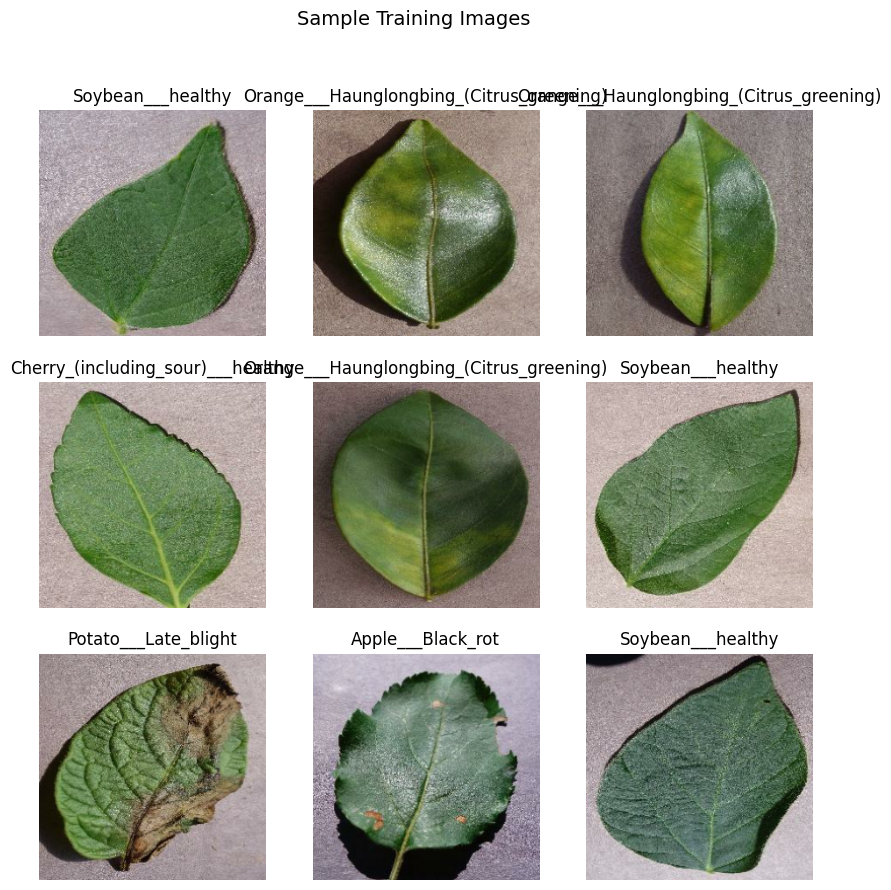

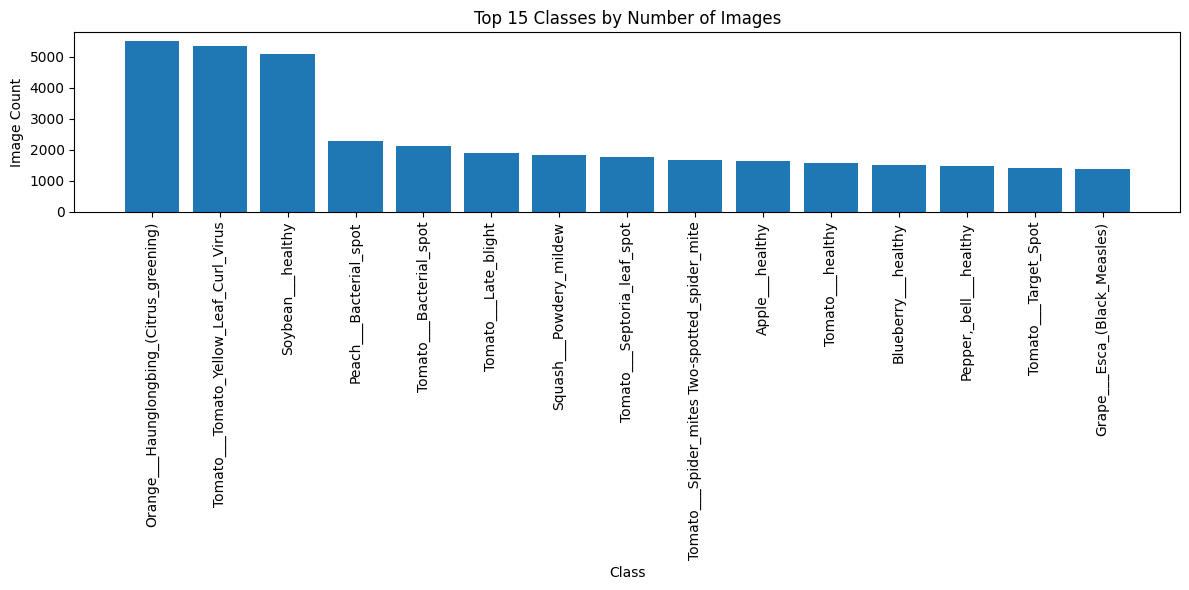

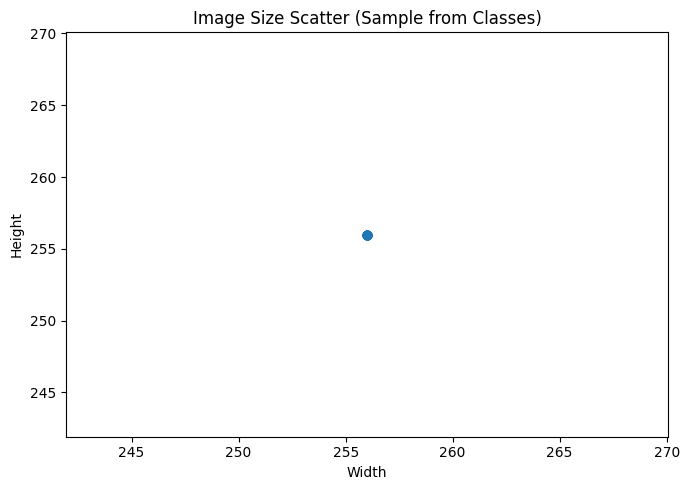

In [8]:
print("\n========== STEP 3: DATA VISUALIZATION ==========")

# Visual 1: Sample images from training set (3x3 grid)
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # show image [web:44]
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.suptitle("Sample Training Images", fontsize=14)
plt.show()

# Visual 2: Class distribution (Top 15 classes by image count)
class_counts = {}

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)

    if os.path.isdir(folder_path):
        class_counts[folder] = len(os.listdir(folder_path))

sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

top_n = 15
labels_top = [x[0] for x in sorted_classes[:top_n]]
counts_top = [x[1] for x in sorted_classes[:top_n]]

plt.figure(figsize=(12, 6))
plt.bar(labels_top, counts_top)  # bar chart for counts [web:42]
plt.xticks(rotation=90)
plt.title("Top 15 Classes by Number of Images")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

# Visual 3: Image size scatter (1 sample image per class)
sample_sizes = []

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)

    if os.path.isdir(folder_path):
        imgs = os.listdir(folder_path)

        if len(imgs) > 0:
            p = os.path.join(folder_path, imgs[0])
            try:
                with Image.open(p) as im:
                    sample_sizes.append(im.size)  # (width, height) tuple [web:55]
            except Exception:
                pass

widths = [s[0] for s in sample_sizes]
heights = [s[1] for s in sample_sizes]

plt.figure(figsize=(7, 5))
plt.scatter(widths, heights)  # scatter plot of width vs height [web:50]
plt.title("Image Size Scatter (Sample from Classes)")
plt.xlabel("Width")
plt.ylabel("Height")
plt.tight_layout()
plt.show()


In [9]:
# =====================================================
#  STEP 4: Pipeline Optimization
# =====================================================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [10]:
# =====================================================
#  STEP 5: Data Augmentation
# =====================================================
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

In [11]:
# =====================================================
#  STEP 6: BUILD RESNET50 TRANSFER LEARNING MODEL
# =====================================================
print("\n========== STEP 6: BUILD RESNET50 MODEL ==========")

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # freeze base model for phase 1 transfer learning [web:71]

inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_aug(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)  # ResNet50 preprocessing (recommended) [web:62]
x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



========== STEP 6: BUILD RESNET50 MODEL ==========
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 38)        │     77,862 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,665,574 (90.28 MB)

 Trainable params: 77,862 (304.15 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
# =====================================================
#  STEP 7: TRAINING PHASE 1 (Head training)
# =====================================================
print("\n========== STEP 7: TRAINING PHASE 1 ==========")

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=3,
        restore_best_weights=True
    ),  # stops when metric stops improving; can restore best weights [web:73]

    tf.keras.callbacks.ReduceLROnPlateau(
        patience=2,
        factor=0.2
    ),  # reduces learning rate when progress plateaus [web:77]

    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, "best_resnet50.h5"),
        save_best_only=True
    )  # saves only the best model checkpoint to the given path [web:81]
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks
)



========== STEP 7: TRAINING PHASE 1 ==========
Epoch 1/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5319 - loss: 1.8534

2716/2716 ━━━━━━━━━━━━━━━━━━━━ 261s 92ms/step - accuracy: 0.5320 - loss: 1.8532 - val_accuracy: 0.9020 - val_loss: 0.3837 - learning_rate: 1.0000e-04
Epoch 2/8
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9008 - loss: 0.4128

2716/2716 ━━━━━━━━━━━━━━━━━━━━ 247s 91ms/step - accuracy: 0.9008 - loss: 0.4128 - val_accuracy: 0.9332 - val_loss: 0.2374 - learning_rate: 1.0000e-04
Epoch 3/8
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9329 - loss: 0.2622

2716/2716 ━━━━━━━━━━━━━━━━━━━━ 247s 91ms/step - accuracy: 0.9329 - loss: 0.2622 - val_accuracy: 0.9406 - val_loss: 0.1968 - learning_rate: 1.0000e-04
Epoch 4/8
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9467 - loss: 0.2028

2716/2716 ━━━━━━━━━━━━━━━━━━━━ 263s 91ms/step - accuracy: 0.9467 - loss: 0.2028 - val_accuracy: 0.9495 - val_loss: 0.1658 - learning_rate: 1.0000e-04
Epoch 5/8
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9549 - loss: 0.1701

2716/2716 ━━━━━━━━━━━━━━━━━━━━ 248s 91ms/step - accuracy: 0.9549 - loss: 0.1701 - val_accuracy: 0.9518 - val_loss: 0.1523 - learning_rate: 1.0000e-04
Epoch 6/8
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9598 - loss: 0.1481

2716/2716 ━━━━━━━━━━━━━━━━━━━━ 248s 91ms/step - accuracy: 0.9598 - loss: 0.1481 - val_accuracy: 0.9515 - val_loss: 0.1480 - learning_rate: 1.0000e-04
Epoch 7/8
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9624 - loss: 0.1351

2716/2716 ━━━━━━━━━━━━━━━━━━━━ 248s 91ms/step - accuracy: 0.9624 - loss: 0.1351 - val_accuracy: 0.9579 - val_loss: 0.1298 - learning_rate: 1.0000e-04
Epoch 8/8
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9667 - loss: 0.1246

2716/2716 ━━━━━━━━━━━━━━━━━━━━ 247s 91ms/step - accuracy: 0.9667 - loss: 0.1246 - val_accuracy: 0.9577 - val_loss: 0.1280 - learning_rate: 1.0000e-04


In [13]:
# =====================================================
#  STEP 8: FINE TUNING (Unfreeze last layers)
# =====================================================
print("\n========== STEP 8: FINE TUNING ==========")

base_model.trainable = True

# Unfreeze last 30 layers only
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=callbacks
)



========== STEP 8: FINE TUNING ==========
Epoch 1/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9139 - loss: 0.3012

2716/2716 ━━━━━━━━━━━━━━━━━━━━ 359s 128ms/step - accuracy: 0.9139 - loss: 0.3011 - val_accuracy: 0.9734 - val_loss: 0.0841 - learning_rate: 1.0000e-05
Epoch 2/5
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9756 - loss: 0.0772

2716/2716 ━━━━━━━━━━━━━━━━━━━━ 343s 126ms/step - accuracy: 0.9756 - loss: 0.0772 - val_accuracy: 0.9784 - val_loss: 0.0644 - learning_rate: 1.0000e-05
Epoch 3/5
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9834 - loss: 0.0534

2716/2716 ━━━━━━━━━━━━━━━━━━━━ 343s 126ms/step - accuracy: 0.9834 - loss: 0.0534 - val_accuracy: 0.9855 - val_loss: 0.0447 - learning_rate: 1.0000e-05
Epoch 4/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9882 - loss: 0.0394

2716/2716 ━━━━━━━━━━━━━━━━━━━━ 343s 126ms/step - accuracy: 0.9882 - loss: 0.0393 - val_accuracy: 0.9868 - val_loss: 0.0412 - learning_rate: 1.0000e-05
Epoch 5/5
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9912 - loss: 0.0290

2716/2716 ━━━━━━━━━━━━━━━━━━━━ 343s 126ms/step - accuracy: 0.9912 - loss: 0.0290 - val_accuracy: 0.9874 - val_loss: 0.0354 - learning_rate: 1.0000e-05


In [14]:

# =====================================================
#  STEP 9: SAVE MODEL
# =====================================================
print("\n========== STEP 9: SAVE MODEL ==========")

model.save(MODEL_PATH)
print(f" Saved model: {MODEL_PATH}")




========== STEP 9: SAVE MODEL ==========
 Saved model: model/plant_resnet50.h5



========== STEP 10: TRAINING CURVES ==========


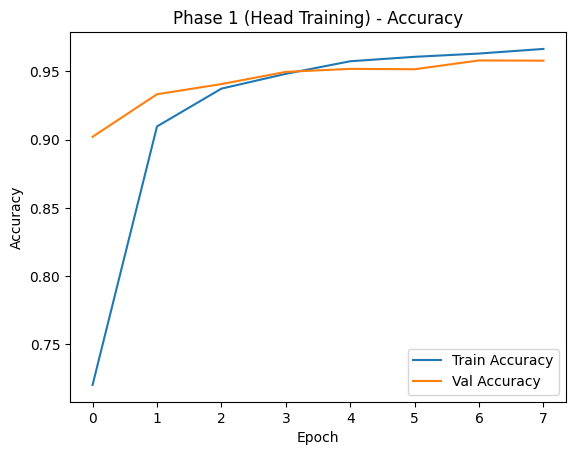

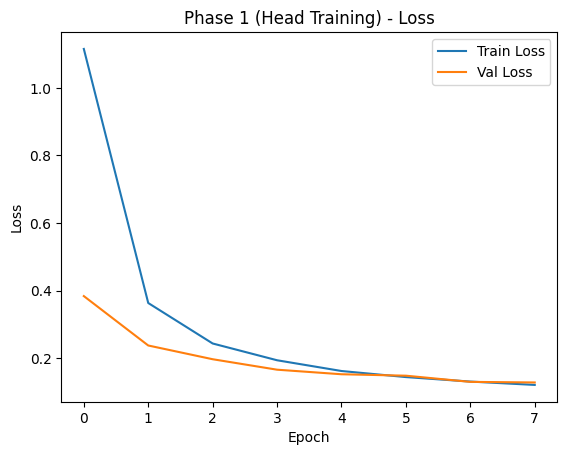

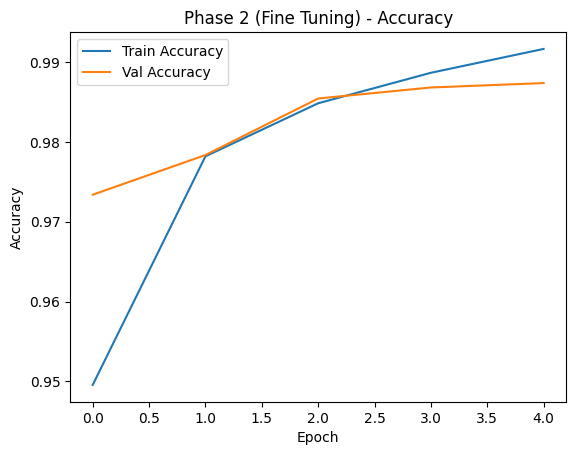

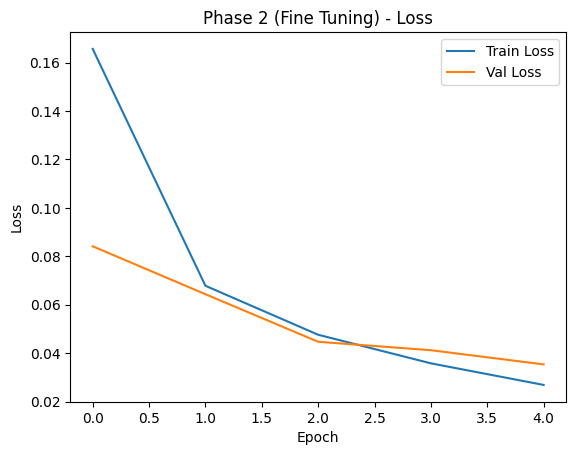

In [15]:

# =====================================================
#  STEP 10: TRAINING CURVES
# =====================================================
print("\n========== STEP 10: TRAINING CURVES ==========")

def plot_curves(history, title):
    plt.figure()
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_curves(history1, "Phase 1 (Head Training)")  # plot from history.history [web:87]
plot_curves(history2, "Phase 2 (Fine Tuning)")    # plot from history.history [web:87]



========== STEP 11: EVALUATION ==========

 Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.99      0.98       126
                                 Apple___Black_rot       1.00      1.00      1.00       132
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.99      1.00      0.99       329
                               Blueberry___healthy       1.00      1.00      1.00       295
          Cherry_(including_sour)___Powdery_mildew       1.00      0.97      0.99       232
                 Cherry_(including_sour)___healthy       1.00      0.98      0.99       167
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.83      0.98      0.90       108
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       219
          

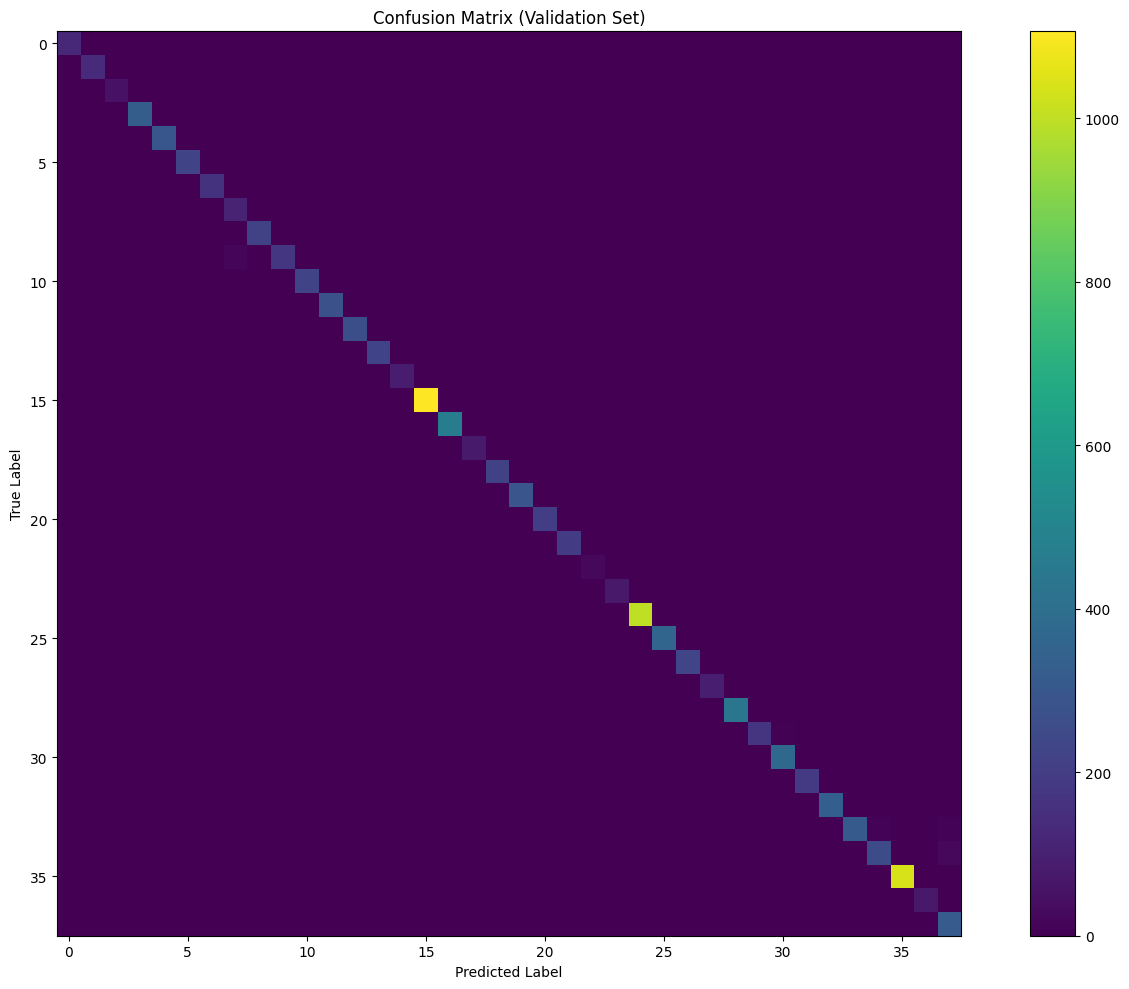


 Done — ResNet50 Training Complete!


In [16]:

# =====================================================
#  STEP 11: EVALUATION (Confusion Matrix + Report)
# =====================================================
print("\n========== STEP 11: EVALUATION ==========")

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)  # pick class with max probability per row [web:92]
    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

print("\n Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 10))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (Validation Set)")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("\n Done — ResNet50 Training Complete!")


In [64]:
new_model_path = os.path.join(MODEL_DIR, "plant_resnet50.keras")
model.save(new_model_path)
print(f" Successfully saved model to: {new_model_path}")

 Successfully saved model to: model/plant_resnet50.keras


In [65]:
print("\n========== Loading the new .keras model ==========")
loaded_keras_model = tf.keras.models.load_model(new_model_path)
print(f" Successfully loaded model from: {new_model_path}")


========== Loading the new .keras model ==========
 Successfully loaded model from: model/plant_resnet50.keras


In [66]:
print("\n========== Getting a sample image for inference ==========")

# Get one batch from the validation dataset
for images, labels in val_ds.take(1):
    sample_image = images[0] # Take the first image
    true_label_idx = labels[0].numpy() # Take its true label index
    break # Exit after taking one batch

true_label_name = class_names[true_label_idx]

print(f" Successfully retrieved sample image with true label: {true_label_name}")


========== Getting a sample image for inference ==========
 Successfully retrieved sample image with true label: Tomato___Bacterial_spot


In [67]:
print("\n========== Preprocessing the sample image ==========")

# Expand dimensions to create a batch of 1 image and preprocess
processed_image = tf.keras.applications.resnet50.preprocess_input(tf.expand_dims(sample_image, axis=0))

print(" Sample image preprocessed and ready for prediction.")


========== Preprocessing the sample image ==========
 Sample image preprocessed and ready for prediction.


In [68]:
print("\n========== Making a prediction ==========")

# Make a prediction with the loaded model
predictions = loaded_keras_model.predict(processed_image)

print(" Prediction made.")


========== Making a prediction ==========


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
 Prediction made.


In [69]:
print("\n========== Determining Predicted Class ==========")

# Get the predicted class label (index of the max probability)
predicted_label_idx = np.argmax(predictions[0])
predicted_label_name = class_names[predicted_label_idx]

print(f" Predicted label: {predicted_label_name}")


========== Determining Predicted Class ==========
 Predicted label: Tomato___Early_blight



========== Displaying Results ==========


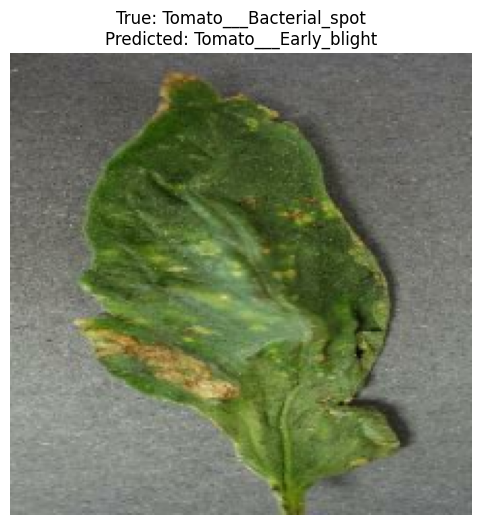

 Displayed sample image with true and predicted labels.


In [70]:
print("\n========== Displaying Results ==========")

plt.figure(figsize=(6, 6))
plt.imshow(sample_image.numpy().astype("uint8"))
plt.title(f"True: {true_label_name}\nPredicted: {predicted_label_name}")
plt.axis("off")
plt.show()

print(" Displayed sample image with true and predicted labels.")

In [71]:
print("\n========== Analyzing Prediction Confidence ==========")

# Get the probabilities for the sample image
probabilities = predictions[0]

# Get the indices that would sort these probabilities in descending order
sorted_indices = np.argsort(probabilities)[::-1]

# Select the top 5 indices
top_n_indices = sorted_indices[:5]

# Store top N predicted class names and their probabilities
top_n_predictions = []
for i in top_n_indices:
    class_name = class_names[i]
    probability = probabilities[i]
    top_n_predictions.append((class_name, probability))

print(" Top 5 predicted classes and their probabilities extracted.")
print("Top N Predictions:")
for class_name, probability in top_n_predictions:
    print(f"  - {class_name}: {probability:.4f}")


========== Analyzing Prediction Confidence ==========
 Top 5 predicted classes and their probabilities extracted.
Top N Predictions:
  - Tomato___Early_blight: 0.3699
  - Tomato___Tomato_Yellow_Leaf_Curl_Virus: 0.2129
  - Tomato___Late_blight: 0.2008
  - Tomato___Leaf_Mold: 0.1081
  - Tomato___Spider_mites Two-spotted_spider_mite: 0.0188


In [72]:
print("\n========== Saving the Retrained Model ==========")

# Define the new path for the retrained model
retrained_model_path = os.path.join(MODEL_DIR, "plant_resnet50_retrained.keras")

# Save the model in the native Keras format
model.save(retrained_model_path)

print(f" Successfully saved retrained model to: {retrained_model_path}")


========== Saving the Retrained Model ==========
 Successfully saved retrained model to: model/plant_resnet50_retrained.keras



========== Displaying Results with Top 5 Confidences ==========


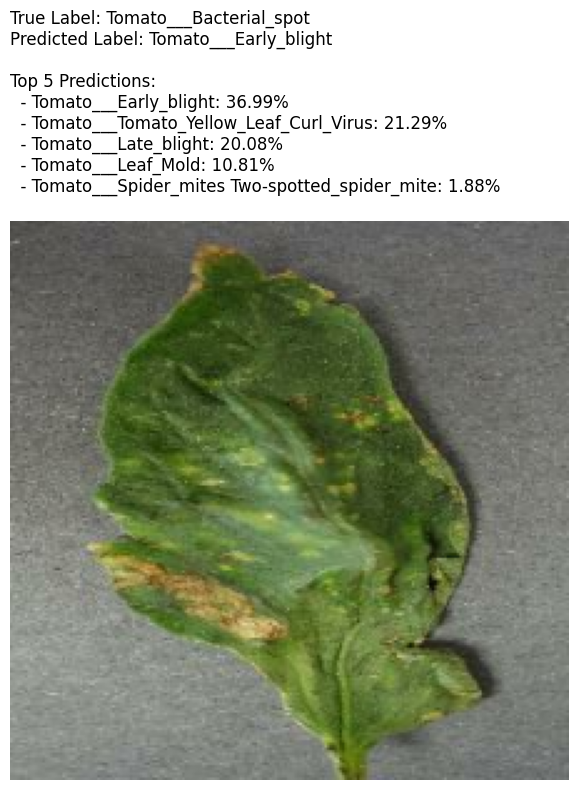

 Displayed sample image with true label, predicted label, and top 5 confidence scores.


In [73]:
print("\n========== Displaying Results with Top 5 Confidences ==========")

plt.figure(figsize=(8, 8))
plt.imshow(sample_image.numpy().astype("uint8"))

title_text = f"True Label: {true_label_name}\nPredicted Label: {predicted_label_name}\n\nTop 5 Predictions:\n"
for class_name, probability in top_n_predictions:
    title_text += f"  - {class_name}: {probability:.2%}\n"

plt.title(title_text, loc='left', fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

print(" Displayed sample image with true label, predicted label, and top 5 confidence scores.")

In [74]:
# =====================================================
#  STEP 5: DATA AUGMENTATION
# =====================================================
data_aug = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),   # random horizontal and vertical flips
        tf.keras.layers.RandomRotation(0.2),        # random small rotations
        tf.keras.layers.RandomZoom(0.2),            # random zoom in/out
        tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1), # random translation
        tf.keras.layers.RandomBrightness(factor=0.2), # random brightness adjustment
        tf.keras.layers.RandomContrast(0.1),        # random contrast change
    ],
    name="data_augmentation"
)

# =====================================================
#  STEP 6: BUILD RESNET50 TRANSFER LEARNING MODEL
# =====================================================
print("\n========== STEP 6: BUILD RESNET50 MODEL ==========")

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # freeze base model for phase 1 transfer learning [web:71]

inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_aug(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)  # ResNet50 preprocessing (recommended) [web:62]
x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



========== STEP 6: BUILD RESNET50 MODEL ==========


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_4 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_4[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 38)        │     77,862 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,665,574 (90.28 MB)

 Trainable params: 77,862 (304.15 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Adjust Fine-tuning Parameters



In [75]:
print("\n========== Adjusting Fine-tuning Parameters ==========")

EPOCHS_FINE = 10

print(f" Updated EPOCHS_FINE to: {EPOCHS_FINE}")


========== Adjusting Fine-tuning Parameters ==========
 Updated EPOCHS_FINE to: 10


In [76]:
# =====================================================
#  STEP 8: FINE TUNING (Unfreeze last layers)
# =====================================================
print("\n========== STEP 8: FINE TUNING ==========")

base_model.trainable = True

# Unfreeze last 30 layers only
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6), # Changed learning rate to 5e-6
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=callbacks
)


========== STEP 8: FINE TUNING ==========
Epoch 1/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 363s 129ms/step - accuracy: 0.4114 - loss: 2.3643 - val_accuracy: 0.8902 - val_loss: 0.3650 - learning_rate: 5.0000e-06
Epoch 2/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 348s 128ms/step - accuracy: 0.8648 - loss: 0.4841 - val_accuracy: 0.9371 - val_loss: 0.1899 - learning_rate: 5.0000e-06
Epoch 3/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 348s 128ms/step - accuracy: 0.9210 - loss: 0.2655 - val_accuracy: 0.9544 - val_loss: 0.1386 - learning_rate: 5.0000e-06
Epoch 4/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 348s 128ms/step - accuracy: 0.9431 - loss: 0.1935 - val_accuracy: 0.9641 - val_loss: 0.1145 - learning_rate: 5.0000e-06
Epoch 5/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 384s 141ms/step - accuracy: 0.9539 - loss: 0.1518 - val_accuracy: 0.9663 - val_loss: 0.1018 - learning_rate: 5.0000e-06
Epoch 6/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 347s 128ms/step - accuracy: 0.9614 - loss: 0.1263 - val_accuracy: 0.9708 - val_loss: 0.0916 - learning_ra

In [77]:
print("\n========== Re-extracting the same sample image for comparison ==========")

# Get one batch from the validation dataset. Due to fixed SEED, this should yield the same sample.
for images, labels in val_ds.take(1):
    sample_image = images[0] # Take the first image
    true_label_idx = labels[0].numpy() # Take its true label index
    break # Exit after taking one batch

true_label_name = class_names[true_label_idx]

print(f" Successfully re-extracted sample image with true label: {true_label_name}")


========== Re-extracting the same sample image for comparison ==========
 Successfully re-extracted sample image with true label: Grape___Esca_(Black_Measles)


In [78]:
print("\n========== Preprocessing the sample image ==========")

# Expand dimensions to create a batch of 1 image and preprocess
processed_image = tf.keras.applications.resnet50.preprocess_input(tf.expand_dims(sample_image, axis=0))

print(" Sample image preprocessed and ready for prediction.")


========== Preprocessing the sample image ==========
 Sample image preprocessed and ready for prediction.


In [79]:
print("\n========== Making a prediction with the newly trained model ==========")

# Make a prediction with the newly trained model
predictions = model.predict(processed_image)

print(" Prediction made with the updated model.")


========== Making a prediction with the newly trained model ==========


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
 Prediction made with the updated model.


In [80]:
print("\n========== Determining Predicted Class ==========")

# Get the predicted class label (index of the max probability)
predicted_label_idx = np.argmax(predictions[0])
predicted_label_name = class_names[predicted_label_idx]

print(f" Predicted label: {predicted_label_name}")


========== Determining Predicted Class ==========
 Predicted label: Grape___Esca_(Black_Measles)


In [81]:
print("\n========== Analyzing Prediction Confidence (Retrained Model) ==========")

# Get the probabilities for the sample image from the newly trained model
probabilities = predictions[0]

# Get the indices that would sort these probabilities in descending order
sorted_indices = np.argsort(probabilities)[::-1]

# Select the top 5 indices
top_n_indices_retrained = sorted_indices[:5]

# Store top N predicted class names and their probabilities
top_n_predictions_retrained = []
for i in top_n_indices_retrained:
    class_name = class_names[i]
    probability = probabilities[i]
    top_n_predictions_retrained.append((class_name, probability))

print(" Top 5 predicted classes and their probabilities extracted for the retrained model.")
print("Top N Predictions (Retrained Model):")
for class_name, probability in top_n_predictions_retrained:
    print(f"  - {class_name}: {probability:.4f}")


========== Analyzing Prediction Confidence (Retrained Model) ==========
 Top 5 predicted classes and their probabilities extracted for the retrained model.
Top N Predictions (Retrained Model):
  - Grape___Esca_(Black_Measles): 0.9942
  - Apple___Black_rot: 0.0027
  - Apple___healthy: 0.0011
  - Strawberry___Leaf_scorch: 0.0006
  - Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 0.0003



========== Displaying Results with Top 5 Confidences (Retrained Model) ==========


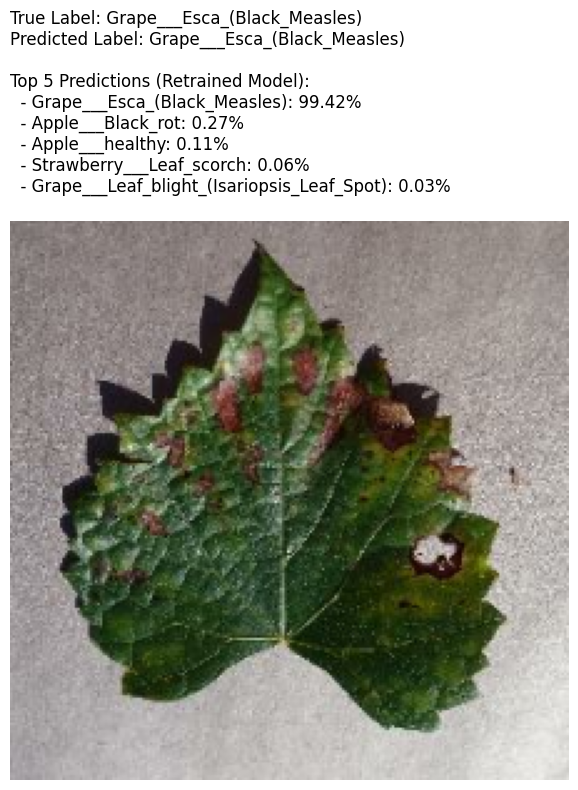

 Displayed sample image with true label, predicted label, and top 5 confidence scores for the retrained model.


In [82]:
print("\n========== Displaying Results with Top 5 Confidences (Retrained Model) ==========")

plt.figure(figsize=(8, 8))
plt.imshow(sample_image.numpy().astype("uint8"))

title_text = f"True Label: {true_label_name}\nPredicted Label: {predicted_label_name}\n\nTop 5 Predictions (Retrained Model):\n"
for class_name, probability in top_n_predictions_retrained:
    title_text += f"  - {class_name}: {probability:.2%}\n"

plt.title(title_text, loc='left', fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

print(" Displayed sample image with true label, predicted label, and top 5 confidence scores for the retrained model.")


========== STEP 10: TRAINING CURVES ==========


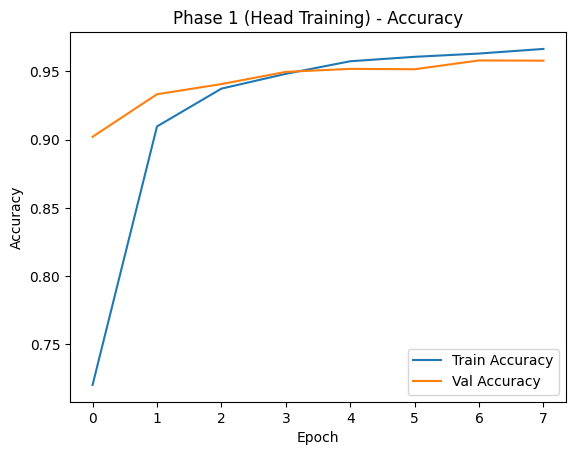

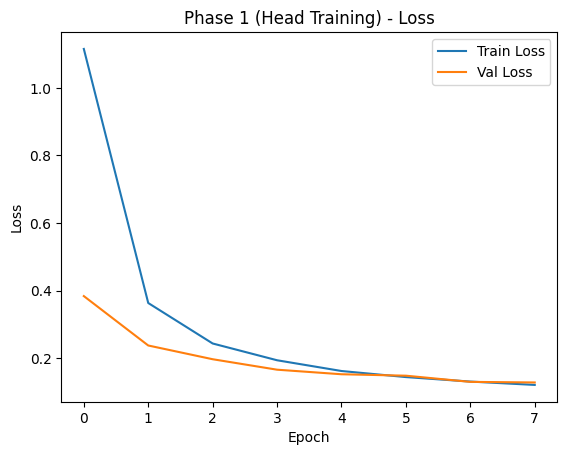

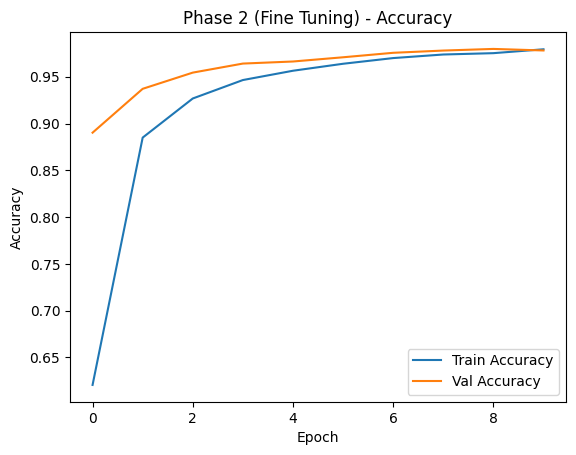

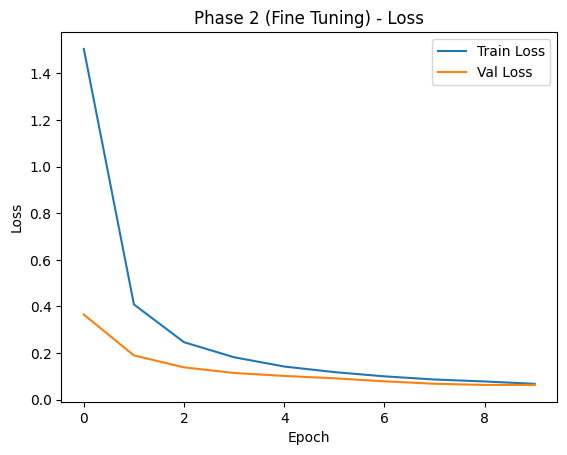

In [85]:
# =====================================================
#  STEP 10: TRAINING CURVES
# =====================================================
print("\n========== STEP 10: TRAINING CURVES ==========")

def plot_curves(history, title):
    plt.figure()
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_curves(history1, "Phase 1 (Head Training)")  # plot from history.history [web:87]
plot_curves(history2, "Phase 2 (Fine Tuning)")    # plot from history.history [web:87]



========== STEP 11: EVALUATION ==========

 Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.94      0.96       126
                                 Apple___Black_rot       1.00      1.00      1.00       132
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.96      1.00      0.98       329
                               Blueberry___healthy       1.00      1.00      1.00       295
          Cherry_(including_sour)___Powdery_mildew       1.00      0.96      0.98       232
                 Cherry_(including_sour)___healthy       0.98      0.98      0.98       167
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.92      0.93       108
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       219
          

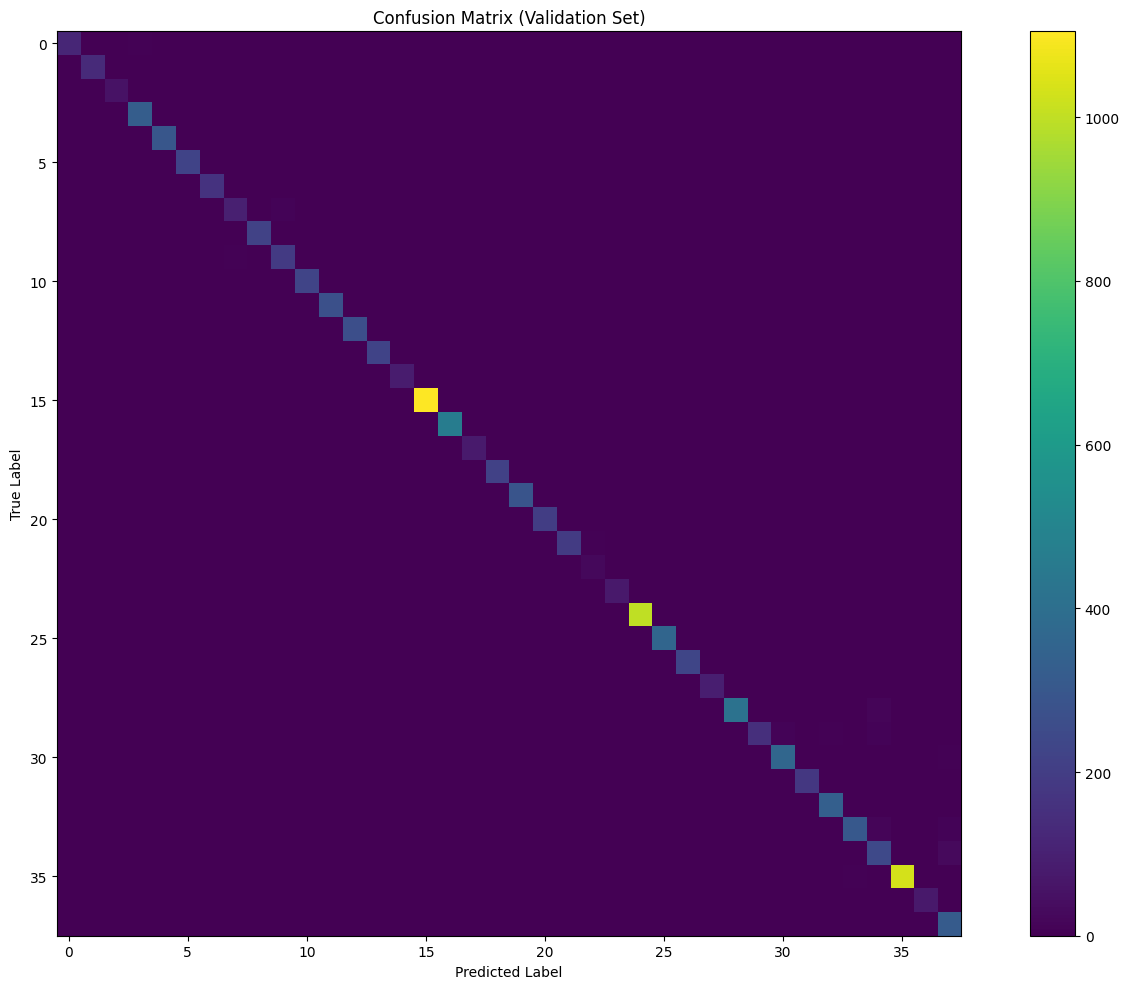


 Done — ResNet50 Training Complete!


In [84]:
# =====================================================
#  STEP 11: EVALUATION (Confusion Matrix + Report)
# =====================================================
print("\n========== STEP 11: EVALUATION ==========")

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)  # pick class with max probability per row [web:92]
    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

print("\n Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 10))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (Validation Set)")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("\n Done — ResNet50 Training Complete!")